In [1]:
library(tidyverse)

players <- read_csv("players.csv")
sessions <- read_csv("sessions.csv")

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.1     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.1
✔ purrr     1.0.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Rows: 196 Columns: 7
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (4): experience, hashedEmail, name, gender
dbl (2): played_hours, Age
lgl (1): subscribe

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 1535 Columns: 5
── Column specification ────────────────────────────────────────────────────────
Delimite

## Understanding the Players Data  
This section reviews the `players.csv` dataset, describing its variables, observation count, and any data issues such as missing values or uneven categories.


In [5]:
players

experience,subscribe,hashedEmail,played_hours,name,gender,Age
<chr>,<lgl>,<chr>,<dbl>,<chr>,<chr>,<dbl>
Pro,TRUE,f6daba428a5e19a3d47574858c13550499be23603422e6a0ee9728f8b53e192d,30.3,Morgan,Male,9
Veteran,TRUE,f3c813577c458ba0dfef80996f8f32c93b6e8af1fa939732842f2312358a88e9,3.8,Christian,Male,17
Veteran,FALSE,b674dd7ee0d24096d1c019615ce4d12b20fcbff12d79d3c5a9d2118eb7ccbb28,0.0,Blake,Male,17
Amateur,TRUE,23fe711e0e3b77f1da7aa221ab1192afe21648d47d2b4fa7a5a659ff443a0eb5,0.7,Flora,Female,21
Regular,TRUE,7dc01f10bf20671ecfccdac23812b1b415acd42c2147cb0af4d48fcce2420f3e,0.1,Kylie,Male,21
Amateur,TRUE,f58aad5996a435f16b0284a3b267f973f9af99e7a89bee0430055a44fa92f977,0.0,Adrian,Female,17
Regular,TRUE,8e594b8953193b26f498db95a508b03c6fe1c24bb5251d392c18a0da9a722807,0.0,Luna,Female,19
Amateur,FALSE,1d2371d8a35c8831034b25bda8764539ab7db0f63938696917c447128a2540dd,0.0,Emerson,Male,21
Amateur,TRUE,8b71f4d66a38389b7528bb38ba6eb71157733df7d1740371852a797ae97d82d1,0.1,Natalie,Male,47


In [9]:
head(players)

nrow(players)

ncol(players)

summary(players)


experience,subscribe,hashedEmail,played_hours,name,gender,Age
<chr>,<lgl>,<chr>,<dbl>,<chr>,<chr>,<dbl>
Pro,TRUE,f6daba428a5e19a3d47574858c13550499be23603422e6a0ee9728f8b53e192d,30.3,Morgan,Male,9
Veteran,TRUE,f3c813577c458ba0dfef80996f8f32c93b6e8af1fa939732842f2312358a88e9,3.8,Christian,Male,17
Veteran,FALSE,b674dd7ee0d24096d1c019615ce4d12b20fcbff12d79d3c5a9d2118eb7ccbb28,0.0,Blake,Male,17
Amateur,TRUE,23fe711e0e3b77f1da7aa221ab1192afe21648d47d2b4fa7a5a659ff443a0eb5,0.7,Flora,Female,21
Regular,TRUE,7dc01f10bf20671ecfccdac23812b1b415acd42c2147cb0af4d48fcce2420f3e,0.1,Kylie,Male,21
Amateur,TRUE,f58aad5996a435f16b0284a3b267f973f9af99e7a89bee0430055a44fa92f977,0.0,Adrian,Female,17


[1] 196

[1] 7

  experience        subscribe       hashedEmail         played_hours    
 Length:196         Mode :logical   Length:196         Min.   :  0.000  
 Class :character   FALSE:52        Class :character   1st Qu.:  0.000  
 Mode  :character   TRUE :144       Mode  :character   Median :  0.100  
                                                       Mean   :  5.846  
                                                       3rd Qu.:  0.600  
                                                       Max.   :223.100  
                                                                        
     name              gender               Age       
 Length:196         Length:196         Min.   : 9.00  
 Class :character   Class :character   1st Qu.:17.00  
 Mode  :character   Mode  :character   Median :19.00  
                                       Mean   :21.14  
                                       3rd Qu.:22.75  
                                       Max.   :58.00  
                               

## Data Description – `players.csv`

**Observations:** 196 **Variables:** 7  

### Summary
| Variable | Type | Meaning | Notes |
|-----------|------|----------|-------|
| experience | Character | Player’s self-reported skill level | Uneven group sizes |
| subscribe | Logical | Newsletter subscription (TRUE/FALSE) | 52 FALSE, 144 TRUE |
| hashedEmail | Character | Unique player ID | Identifier only |
| played_hours | Numeric | Total playtime (hours) | Range 0–223 we can check for outliers later |
| name | Character | Player display name | Identifier only |
| gender | Character | Player gender | Possibly unbalanced |
| Age | Numeric | Player age (years) | Two missing values (NA) |

## Tidiness
Each row corresponds to a single player and each column stores one variable, so the dataset is already **tidy**.
No additional wrangling is required to make the data suitable for analysis.

### Key Stats
Mean playtime = 5.83 h Mean age = 19.2 y  
Age range = 9–58 Playtime range = 0–223  


## Understanding the Sessions Data
This section reviews the `sessions.csv` dataset, outlining its variables, number of observations, and any data irregularities. It provides context for how this dataset complements `players.csv` before later analysis.


In [7]:
sessions

hashedEmail,start_time,end_time,original_start_time,original_end_time
<chr>,<chr>,<chr>,<dbl>,<dbl>
bfce39c89d6549f2bb94d8064d3ce69dc3d7e72b38f431d8aa0c4bf95ccee6bf,30/06/2024 18:12,30/06/2024 18:24,1.71977e+12,1.71977e+12
36d9cbb4c6bc0c1a6911436d2da0d09ec625e43e6552f575d4acc9cf487c4686,17/06/2024 23:33,17/06/2024 23:46,1.71867e+12,1.71867e+12
f8f5477f5a2e53616ae37421b1c660b971192bd8ff77e3398304c7ae42581fdc,25/07/2024 17:34,25/07/2024 17:57,1.72193e+12,1.72193e+12
bfce39c89d6549f2bb94d8064d3ce69dc3d7e72b38f431d8aa0c4bf95ccee6bf,25/07/2024 03:22,25/07/2024 03:58,1.72188e+12,1.72188e+12
36d9cbb4c6bc0c1a6911436d2da0d09ec625e43e6552f575d4acc9cf487c4686,25/05/2024 16:01,25/05/2024 16:12,1.71665e+12,1.71665e+12
bfce39c89d6549f2bb94d8064d3ce69dc3d7e72b38f431d8aa0c4bf95ccee6bf,23/06/2024 15:08,23/06/2024 17:10,1.71916e+12,1.71916e+12
fd6563a4e0f6f4273580e5fedbd8dda64990447aea5a33cbb5e894a3867ca44d,15/04/2024 07:12,15/04/2024 07:21,1.71317e+12,1.71317e+12
ad6390295640af1ed0e45ffc58a53b2d9074b0eea694b16210addd44d7c81f83,21/09/2024 02:13,21/09/2024 02:30,1.72688e+12,1.72689e+12
96e190b0bf3923cd8d349eee467c09d1130af143335779251492eb4c2c058a5f,21/06/2024 02:31,21/06/2024 02:49,1.71894e+12,1.71894e+12


In [8]:
head(sessions)

nrow(sessions)
ncol(sessions)

summary(sessions)

hashedEmail,start_time,end_time,original_start_time,original_end_time
<chr>,<chr>,<chr>,<dbl>,<dbl>
bfce39c89d6549f2bb94d8064d3ce69dc3d7e72b38f431d8aa0c4bf95ccee6bf,30/06/2024 18:12,30/06/2024 18:24,1.71977e+12,1.71977e+12
36d9cbb4c6bc0c1a6911436d2da0d09ec625e43e6552f575d4acc9cf487c4686,17/06/2024 23:33,17/06/2024 23:46,1.71867e+12,1.71867e+12
f8f5477f5a2e53616ae37421b1c660b971192bd8ff77e3398304c7ae42581fdc,25/07/2024 17:34,25/07/2024 17:57,1.72193e+12,1.72193e+12
bfce39c89d6549f2bb94d8064d3ce69dc3d7e72b38f431d8aa0c4bf95ccee6bf,25/07/2024 03:22,25/07/2024 03:58,1.72188e+12,1.72188e+12
36d9cbb4c6bc0c1a6911436d2da0d09ec625e43e6552f575d4acc9cf487c4686,25/05/2024 16:01,25/05/2024 16:12,1.71665e+12,1.71665e+12
bfce39c89d6549f2bb94d8064d3ce69dc3d7e72b38f431d8aa0c4bf95ccee6bf,23/06/2024 15:08,23/06/2024 17:10,1.71916e+12,1.71916e+12


[1] 1535

[1] 5

 hashedEmail         start_time          end_time         original_start_time
 Length:1535        Length:1535        Length:1535        Min.   :1.712e+12  
 Class :character   Class :character   Class :character   1st Qu.:1.716e+12  
 Mode  :character   Mode  :character   Mode  :character   Median :1.719e+12  
                                                          Mean   :1.719e+12  
                                                          3rd Qu.:1.722e+12  
                                                          Max.   :1.727e+12  
                                                                             
 original_end_time  
 Min.   :1.712e+12  
 1st Qu.:1.716e+12  
 Median :1.719e+12  
 Mean   :1.719e+12  
 3rd Qu.:1.722e+12  
 Max.   :1.727e+12  
 NA's   :2          

## Data Description – `sessions.csv`

**Observations:** 1,535 **Variables:** 5  

### Summary
| Variable | Type | Meaning | Notes |
|-----------|------|----------|-------|
| hashedEmail | Character | Unique player ID | Used to link with `players.csv` |
| start_time | Character | When the session began | Stored as text |
| end_time | Character | When the session ended | Stored as text |
| original_start_time | Numeric | Start time in numeric form | Scientific notation; unclear units |
| original_end_time | Numeric | End time in numeric form | Two missing values (NA) |

### Tidiness
Each row represents a single gameplay session, and each column represents a different variable, so the dataset is **tidy**.  
However, the numeric time columns use scientific notation with unclear units, so converting them to a readable time format would be ideal for if we were to vizualize and analyze this data set in the future


### Key Stats
- **Sessions:** 1,535  
- **Variables:** 5  
- **Numeric time columns** stored in scientific notation and may need formatting for readability.
- **Missing values:** 2 in `original_end_time`  
- **Time range:** sessions appear to span roughly **April–August 2024**  


## Questions

### Broad Question
What features of players might help explain or predict whether they decide to subscribe to the game’s newsletter?

### Specific Exploratory Question
Can a player’s age and total playtime help explain patterns in who subscribes to the game’s newsletter?

### Response and Explanatory Variables
- **Response variable:** `subscribe` (TRUE or FALSE)
- **Explanatory variables:** `Age`, `played_hours`

## Exploring the Data

We will examine players.csv to better understand each variable, look for errors, and visualize significant patterns.


In [12]:
players

experience,subscribe,hashedEmail,played_hours,name,gender,Age
<chr>,<lgl>,<chr>,<dbl>,<chr>,<chr>,<dbl>
Pro,TRUE,f6daba428a5e19a3d47574858c13550499be23603422e6a0ee9728f8b53e192d,30.3,Morgan,Male,9
Veteran,TRUE,f3c813577c458ba0dfef80996f8f32c93b6e8af1fa939732842f2312358a88e9,3.8,Christian,Male,17
Veteran,FALSE,b674dd7ee0d24096d1c019615ce4d12b20fcbff12d79d3c5a9d2118eb7ccbb28,0.0,Blake,Male,17
Amateur,TRUE,23fe711e0e3b77f1da7aa221ab1192afe21648d47d2b4fa7a5a659ff443a0eb5,0.7,Flora,Female,21
Regular,TRUE,7dc01f10bf20671ecfccdac23812b1b415acd42c2147cb0af4d48fcce2420f3e,0.1,Kylie,Male,21
Amateur,TRUE,f58aad5996a435f16b0284a3b267f973f9af99e7a89bee0430055a44fa92f977,0.0,Adrian,Female,17
Regular,TRUE,8e594b8953193b26f498db95a508b03c6fe1c24bb5251d392c18a0da9a722807,0.0,Luna,Female,19
Amateur,FALSE,1d2371d8a35c8831034b25bda8764539ab7db0f63938696917c447128a2540dd,0.0,Emerson,Male,21
Amateur,TRUE,8b71f4d66a38389b7528bb38ba6eb71157733df7d1740371852a797ae97d82d1,0.1,Natalie,Male,47


In [10]:
colSums(is.na(players))

experience    subscribe  hashedEmail played_hours         name       gender 
           0            0            0            0            0            0 
         Age 
           2

Only Age had two missing values, which R will ignore automatically.

In [4]:
players |>
  summarize(mean_played_hours = mean(played_hours, na.rm = TRUE),mean_age = mean(Age, na.rm = TRUE))

mean_played_hours,mean_age
<dbl>,<dbl>
5.845918,21.13918


## Mean Values — `players.csv`

We calculate the mean for each **quantitative variable** in the dataset.  
Only two variables are numeric ('played_hours' and 'Age'), so only these can be used to calculate averages.  
Other variables are categorical identifiers or labels, which are **not** included.

### Mean Table

| Variable        | Mean Value |
|-----------------|------------|
| played_hours    | 5.85       |
| Age             | 21.14      |



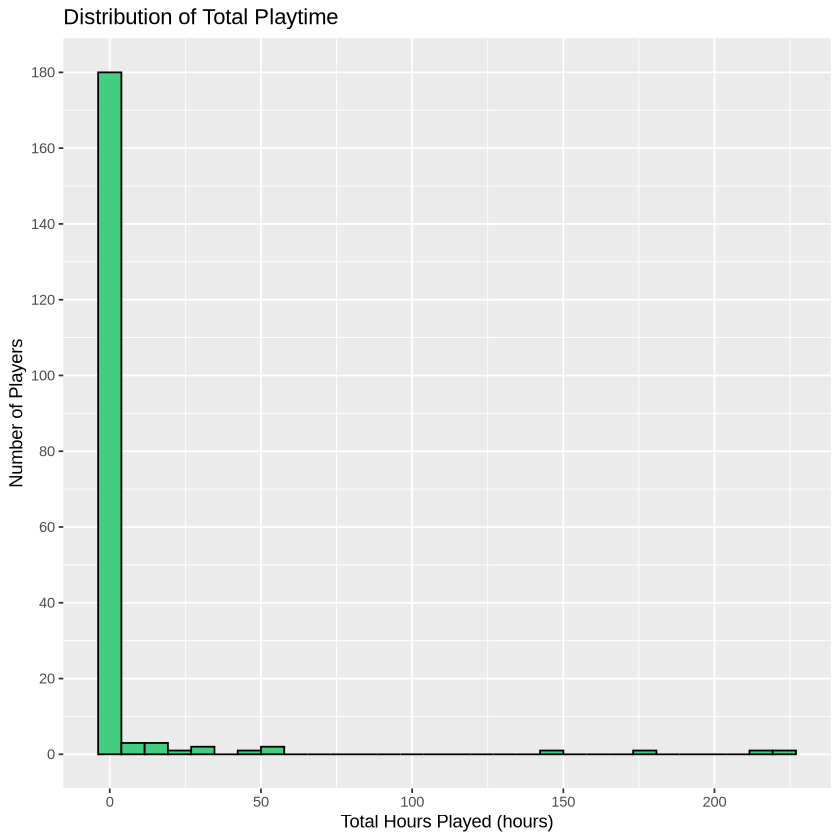

In [29]:
ggplot(players, aes(x = played_hours)) +
  geom_histogram(bins = 30, fill = "seagreen3", color = "black") +
  scale_y_continuous(breaks = seq(0, 200, by = 20)) +
  labs(title = "Distribution of Total Playtime",x = "Total Hours Played (hours)",y = "Number of Players")

### Distribution of Total Playtime
Most players had low playtime, with a small group logging very high hours.

Warning message:
“Removed 2 rows containing non-finite outside the scale range (`stat_bin()`).”


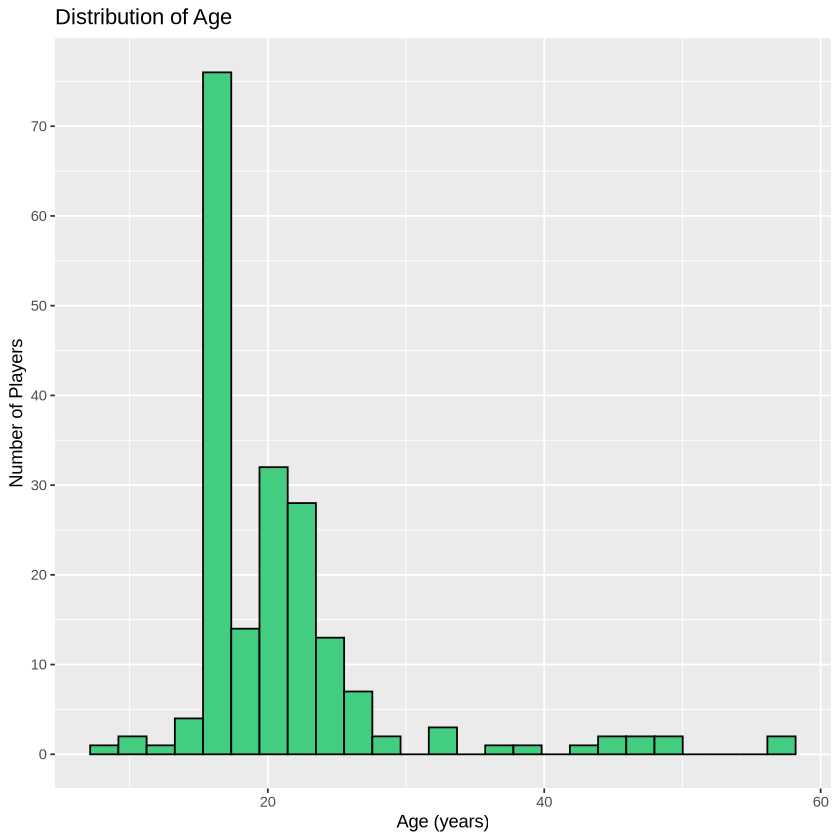

In [31]:
ggplot(players, aes(x = Age)) +
  geom_histogram(bins = 25, fill = "seagreen3", color = "black") +
  scale_y_continuous(breaks = seq(0, 80, by = 10)) +
  labs(title = "Distribution of Age",x = "Age (years)",y = "Number of Players") 

### Distribution of Age
Most players were under 25, with only a few older players, showing a young player base.

Warning message:
“Removed 2 rows containing missing values or values outside the scale range
(`geom_point()`).”


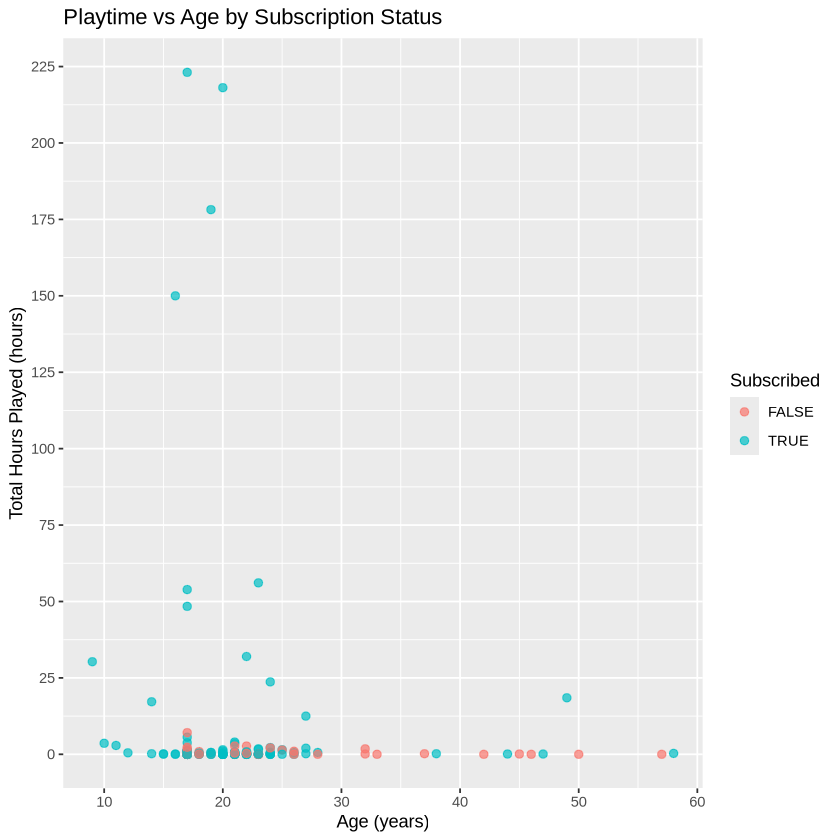

In [24]:
ggplot(players, aes(x = Age, y = played_hours, color = subscribe)) +
  geom_point(alpha = 0.7, size = 2) +
  scale_y_continuous(breaks = seq(0, 250, by = 25)) +
  labs(title = "Playtime vs Age by Subscription Status",x = "Age (years)",y = "Total Hours Played (hours)",color = "Subscribed")

### Playtime vs Age by Subscription Status
Most players under 25 have low to moderate playtime, however a few have incredibly long hours and are typically subscribed.  
Older participants play less overall, suggesting that younger, more active players are more likely to maintain their subscriptions.


### Methods and Plan

We will use a k-nearest neighbours (KNN) classifier to determine if a player subscribes based on age and played_hours.  KNN is appropriate since the outcome is  binary and the predictors are numerical, allowing distance-related classification without relying on a linear relationship.  This approach assumes that players of similar ages and playtime show similar subscription behaviours, and that predictors are standardized. Some limitations are sensitivity to K choice, outliers, and class imbalances.  On the training set, we will compare models using 5-fold cross-validation to find the K with the highest accuracy.  Before tuning and evaluation, the data will be standardized using a recipe. k

### Github Repository Link
https://github.com/cassidoi/dsci-100-2025w1-group36-cassidy.git